# Essay I — Quarterly Panel Pipeline

Builds a firm-quarter panel from the quarterly variance decomposition (`Thesis_2_quarterly.py`) and quarterly firm controls (`quarterly_` sheet), then estimates firm + quarter fixed-effects regressions.

Key differences from the annual pipeline:
- Decomposition: `run_thesis2_quarterly_from_daily_panel` (3-component: Market / Firm / Noise)
- Controls: from the `quarterly_` Bloomberg sheet (20 variables at quarter-end frequency)
- Period dimension: `YYYY-QN` (44 quarters, 2015-Q1 to 2025-Q4)
- Lags / diffs: one-quarter (not one-year)
- Time FE indexed by `pd.PeriodIndex` with `freq="Q"`

In [1]:
import sys
import time
from pathlib import Path

SCRIPTS_DIR = Path(".").resolve()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS

pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

PROJECT_DIR = SCRIPTS_DIR.parent
DATA_DIR    = PROJECT_DIR / "Data"
OUTPUTS_DIR = PROJECT_DIR / "Outputs" / "quarterly_regression"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

from data_interface import (read_bloomberg_two_row_sheet,
                             split_price_volume,
                             build_daily_canonical_panel)
from Thesis_2_quarterly import run_thesis2_quarterly_from_daily_panel

print("Imports OK")
print(f"PROJECT_DIR : {PROJECT_DIR}")

ModuleNotFoundError: No module named 'linearmodels'

## Configuration

Edit `OUTCOME_VARS` and `CONTROL_VARS` to change what the regression estimates.

In [ ]:
# ================================================================
# REGRESSION CONFIGURATION — edit these to set up your analysis
# ================================================================

# Only thesis2_quarterly is available (3-component decomposition).
# Outcomes: FirmInfoShare, MktInfoShare, NoiseShare
OUTCOME_VARS: list = ["FirmInfoShare", "MktInfoShare", "NoiseShare"]

# Independent variables. Three prefixes supported (applied automatically):
#   L1_<VAR>  -> one-quarter lag            X_{i,t-1}
#   D_<VAR>   -> quarter-over-quarter diff   X_{i,t} - X_{i,t-1}
#   <VAR>     -> contemporaneous level       X_{i,t}
#
# Bloomberg quarterly variables (% non-missing across all stock-quarters):
#   CUR_MKT_CAP 94.6%   VOLATILITY_90D 94.4%   PCT_INSIDER_SHARES_OUT 93.2%
#   GOVERNANCE_SCORE 85.4%   ESG_SCORE 83.8%   ENVIRONMENTAL_SCORE 83.8%
#   SOCIAL_SCORE 83.8%   BS_TOT_ASSET 62.2%   HEADLINE_BVPS 61.1%
#   PROF_MARGIN 60.0%   ASSET_TURNOVER 56.9%   FNCL_LVRG 55.0%
#   RETURN_COM_EQY 54.4%   CASH_FLOW_PER_SH 51.2%   HEADLINE_CAPEX 48.7%
#   BEST_EPS_STDDEV 9.1%   SHORT_INT_RATIO 3.2%
#   LOG_MKT_CAP (derived from CUR_MKT_CAP, 94.6%)
#   (INVSTMNT_IN_SUSTNBLE_PRODCTS and ESG_DISCLOSURE_SCORE: 0%, excluded)
#
# Computed volatility (from daily log-returns, replaces Bloomberg VOLATILITY_90D):
#   REALISED_VOL_Q  — annualised realised vol = std(log_ret) * sqrt(65) per quarter.
#                     Coverage ~100% for all stocks present in the daily panel.
#                     Use like any other variable, e.g. L1_REALISED_VOL_Q.
#
# Volatility source switch — controls which measure enters the regression:
#   "bloomberg"  -> L1_VOLATILITY_90D   (Bloomberg 90-day vol, 94.4% coverage)
#   "computed"   -> L1_REALISED_VOL_Q   (computed from daily returns, ~100% coverage)
VOLATILITY_SOURCE: str = "computed"   # "bloomberg" | "computed"

_vol_ctrl = "L1_REALISED_VOL_Q" if VOLATILITY_SOURCE == "computed" else "L1_VOLATILITY_90D"

CONTROL_VARS: list = [
    "D_ESG_SCORE",       # quarter-over-quarter ESG change
    "L1_LOG_MKT_CAP",   # lagged log market cap
    _vol_ctrl,           # lagged volatility (source set by VOLATILITY_SOURCE above)
    "L1_CASH_FLOW_PER_SH",  # lagged cash flow per share
]

# Tag appended to output filenames so robustness runs don't overwrite main results.
RUN_TAG = ""

# ---- pipeline settings ----
START_YEAR    = 2015
END_YEAR      = 2025
DATA_FILE     = DATA_DIR / "data.xlsx"
DAILY_SHEET   = "daily_"
QUARTERLY_SHEET = "quarterly_"
MARKET_TICKER = "SXXP Index"
MAX_STOCKS    = None   # set e.g. to 20 for a quick smoke test

# Set True to recompute decomposition from raw data (required after updating data.xlsx).
FORCE_RECOMPUTE = False

# ================================================================
print(f"Y              : {OUTCOME_VARS}")
print(f"X              : {CONTROL_VARS}")
print(f"Vol source     : {VOLATILITY_SOURCE}  ({_vol_ctrl})")
print(f"Period         : {START_YEAR}–{END_YEAR} (quarterly)  |  tag: '{RUN_TAG}'")
print(f"Stocks         : {'all' if MAX_STOCKS is None else MAX_STOCKS}")
print(f"Cache          : {'DISABLED (FORCE_RECOMPUTE=True)' if FORCE_RECOMPUTE else 'enabled'}")

Y              : ['FirmInfoShare', 'MktInfoShare', 'NoiseShare']
X              : ['D_ESG_SCORE', 'L1_LOG_MKT_CAP', 'L1_REALISED_VOL_Q', 'L1_CASH_FLOW_PER_SH']
Vol source     : computed  (L1_REALISED_VOL_Q)
Period         : 2015–2025 (quarterly)  |  tag: ''
Stocks         : all
Cache          : enabled


## Helper functions

In [ ]:
def standardize_decomposition_output(raw_results):
    """Standardize quarterly decomp output, extracting year and quarter from period string."""
    df = raw_results.copy()
    # period is like "2015-Q1"
    if "period" in df.columns:
        df["year"]    = df["period"].str[:4].astype(int)
        df["quarter"] = df["period"].str[-1].astype(int)
    df["decomp_model"]      = "thesis2_quarterly"
    df["noise_share_proxy"] = pd.to_numeric(df.get("NoiseShare"),  errors="coerce")
    df["total_var"]         = pd.to_numeric(df.get("TotalVar"),    errors="coerce")
    for col in ["MktInfoShare", "FirmInfoShare", "NoiseShare"]:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")
    base  = ["stock", "period", "year", "quarter", "decomp_model",
             "noise_share_proxy", "total_var", "MktInfoShare", "FirmInfoShare", "NoiseShare"]
    other = [c for c in df.columns if c not in base]
    return df[base + other].copy()


def apply_sample_filters(panel_df, start_year, end_year):
    df = panel_df.copy()
    df = df[df["year"].between(start_year, end_year, inclusive="both")]
    for col in ["MktInfoShare", "FirmInfoShare", "NoiseShare"]:
        if col in df.columns:
            valid = df[col].isna() | ((df[col] >= 0) & (df[col] <= 100))
            df = df[valid]
    df = df[df["noise_share_proxy"].notna()]
    if "total_var" in df.columns:
        df = df[(df["total_var"].isna()) | (df["total_var"] > 0)]
    return df.reset_index(drop=True)


print("Helper functions defined")

Helper functions defined


## Regression functions

In [ ]:
def _fit_clustered_fe_panel(df, outcome_col, control_cols):
    """Firm + quarter FE regression with stock-clustered SE."""
    quarterly_cols = [f"{c}_q" for c in control_cols if f"{c}_q" in df.columns]
    reg_df = df[["stock", "period", outcome_col] + quarterly_cols].copy()
    for col in [outcome_col] + quarterly_cols:
        reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")
    reg_df = reg_df.dropna()

    _empty = dict(outcome=outcome_col, controls=control_cols,
                  n_obs=0, n_stocks=0, n_periods=0,
                  multiple_r=np.nan, r_square=np.nan, adj_r_square=np.nan,
                  std_error_regression=np.nan,
                  df_reg=np.nan, df_resid=np.nan, df_total=np.nan,
                  ss_reg=np.nan, ss_resid=np.nan, ss_total=np.nan,
                  ms_reg=np.nan, ms_resid=np.nan,
                  f_stat=np.nan, f_pval=np.nan, coef_table=[], error=None)

    if len(reg_df) == 0 or reg_df["stock"].nunique() < 2 or reg_df["period"].nunique() < 2:
        _empty.update(n_obs=int(len(reg_df)),
                      n_stocks=int(reg_df["stock"].nunique()) if len(reg_df) > 0 else 0,
                      n_periods=int(reg_df["period"].nunique()) if len(reg_df) > 0 else 0,
                      error="Insufficient variation for FE estimation.")
        return _empty

    # Convert "YYYY-QN" to integer ordinal (year*4 + quarter-1) — linearmodels 6.x
    # requires the time dimension to be numeric or datetime, not pd.Period.
    reg_df["period_idx"] = reg_df["period"].apply(
        lambda p: int(p[:4]) * 4 + int(p[-1]) - 1
    )
    reg_df = reg_df.set_index(["stock", "period_idx"]).sort_index()
    y, x = reg_df[outcome_col], reg_df[quarterly_cols]

    try:
        fitted   = PanelOLS(dependent=y, exog=x,
                            entity_effects=True, time_effects=True,
                            drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
        n, k     = int(fitted.nobs), len(fitted.params)
        ss_resid = float((fitted.resids ** 2).sum())
        r2       = float(fitted.rsquared_within)
        ss_total = ss_resid / (1.0 - r2) if r2 < 1.0 else np.nan
        ss_reg   = (ss_total - ss_resid) if not np.isnan(ss_total) else np.nan
        df_resid = int(fitted.df_resid)
        ms_reg   = ss_reg   / k        if k        > 0 and not np.isnan(ss_reg)  else np.nan
        ms_resid = ss_resid / df_resid if df_resid > 0 else np.nan
        rmse     = float(np.sqrt(ms_resid)) if not np.isnan(ms_resid) else np.nan
        adj_r2   = float(1.0 - (1.0 - r2) * (n - 1) / (n - k - 1)) if (n - k - 1) > 0 else np.nan
        try:    f_stat, f_pval = float(fitted.f_statistic.stat), float(fitted.f_statistic.pval)
        except: f_stat, f_pval = np.nan, np.nan
        ci = fitted.conf_int()
        coef_table = [{"variable": v,
                       "coef":      float(fitted.params[v]),
                       "se":        float(fitted.std_errors[v]),
                       "t_stat":    float(fitted.tstats[v]),
                       "p_value":   float(fitted.pvalues[v]),
                       "lower_95":  float(ci.loc[v, "lower"]),
                       "upper_95":  float(ci.loc[v, "upper"])} for v in fitted.params.index]
        return dict(outcome=outcome_col, controls=control_cols,
                    n_obs=n,
                    n_stocks=int(reg_df.index.get_level_values(0).nunique()),
                    n_periods=int(reg_df.index.get_level_values(1).nunique()),
                    multiple_r=float(np.sqrt(r2)), r_square=r2,
                    adj_r_square=adj_r2, std_error_regression=rmse,
                    df_reg=k, df_resid=df_resid, df_total=n - 1,
                    ss_reg=ss_reg, ss_resid=ss_resid, ss_total=ss_total,
                    ms_reg=ms_reg, ms_resid=ms_resid,
                    f_stat=f_stat, f_pval=f_pval, coef_table=coef_table, error=None)
    except Exception as exc:
        r = dict(_empty)
        r.update(n_obs=int(len(reg_df)),
                 n_stocks=int(reg_df.index.get_level_values(0).nunique()),
                 n_periods=int(reg_df.index.get_level_values(1).nunique()),
                 error=str(exc))
        return r


def run_fe_regressions(panel_df, outcome_vars, control_vars):
    available = [c for c in outcome_vars if c in panel_df.columns]
    return [_fit_clustered_fe_panel(panel_df, o, control_vars) for o in available]


def _rows_for_block(result):
    out = result["outcome"]
    controls_str = " + ".join(f"{c}_q" for c in result["controls"])
    def _f(v, d=6):
        if v is None or (isinstance(v, float) and np.isnan(v)): return ""
        if isinstance(v, (int, np.integer)): return int(v)
        return round(float(v), d)
    rows = []
    rows += [[f"Regression: {out} ~ {controls_str}", "", "", "", "", "", ""],
             ["Model: PanelOLS  |  Entity + time FE  |  Stock-clustered SE", "", "", "", "", "", ""],
             [""]]
    rows += [["Regression Statistics"],
             ["Multiple R",        _f(result["multiple_r"])],
             ["R Square (within)", _f(result["r_square"])],
             ["Adjusted R Square", _f(result["adj_r_square"])],
             ["Standard Error",    _f(result["std_error_regression"])],
             ["Observations",      result["n_obs"]],
             ["Unique stocks",     result["n_stocks"]],
             ["Unique quarters",   result["n_periods"]]]
    if result.get("error"):
        rows.append(["Note", result["error"]])
    rows.append([""])
    rows += [["ANOVA", "", "", "", "", ""],
             ["", "df", "SS", "MS", "F", "Significance F"],
             ["Regression", result["df_reg"],   _f(result["ss_reg"]),   _f(result["ms_reg"]),   _f(result["f_stat"]), _f(result["f_pval"])],
             ["Residual",   result["df_resid"], _f(result["ss_resid"]), _f(result["ms_resid"]), "", ""],
             ["Total",      result["df_total"], _f(result["ss_total"]), "", "", ""],
             [""]]
    rows.append(["", "Coefficients", "Standard Error", "t Stat", "P-value", "Lower 95%", "Upper 95%"])
    for r in result["coef_table"]:
        rows.append([r["variable"], _f(r["coef"]), _f(r["se"]), _f(r["t_stat"]),
                     _f(r["p_value"]), _f(r["lower_95"]), _f(r["upper_95"])])
    rows += [[""], [""]]
    return rows


def save_regression_table(results, path):
    all_rows = []
    for r in results:
        all_rows.extend(_rows_for_block(r))
    w = max((len(r) for r in all_rows), default=7)
    pd.DataFrame([r + [""] * (w - len(r)) for r in all_rows]).to_csv(path, index=False, header=False)


print("Regression functions defined")

Regression functions defined


## Step 1 — Run quarterly variance decomposition

Loads the daily returns panel and runs the quarterly Thesis 2 decomposition. Takes ~5–10 minutes for the full universe.

In [ ]:
_cache_decomp = OUTPUTS_DIR / "quarterly_decomp.pkl"
_cache_vol    = OUTPUTS_DIR / "quarterly_realised_vol.pkl"

_use_cache = (not FORCE_RECOMPUTE) and (MAX_STOCKS is None) \
             and _cache_decomp.exists() and _cache_vol.exists()

if _use_cache:
    print("Loading from cache  (set FORCE_RECOMPUTE=True to rerun from scratch)")
    t0 = time.time()
    decomp_results       = pd.read_pickle(_cache_decomp)
    _realised_vol_cached = pd.read_pickle(_cache_vol)
    daily = None
    print(f"  decomp : {len(decomp_results):,} rows, "
          f"{decomp_results['stock'].nunique()} stocks, "
          f"{decomp_results['period'].nunique()} quarters  ({time.time()-t0:.1f}s)")
    print(f"  vol    : {len(_realised_vol_cached):,} firm-quarters")

else:
    print("Loading daily_ sheet…")
    t0 = time.time()
    _daily_raw = read_bloomberg_two_row_sheet(DATA_FILE, sheet_name=DAILY_SHEET)
    _parts     = split_price_volume(_daily_raw)
    daily      = build_daily_canonical_panel(_parts["prices"], _parts["volume"],
                                             market_ticker=MARKET_TICKER)
    print(f"  {daily['stock'].nunique()} stocks, {len(daily):,} rows  ({time.time()-t0:.1f}s)")

    if MAX_STOCKS is not None:
        keep  = daily["stock"].drop_duplicates().head(MAX_STOCKS)
        daily = daily[daily["stock"].isin(keep)].copy()
        print(f"  Capped to {daily['stock'].nunique()} stocks (MAX_STOCKS={MAX_STOCKS})")

    # Pre-compute quarter-level realised volatility while daily panel is in memory.
    _daily_vol = daily.copy()
    _daily_vol["date"]    = pd.to_datetime(_daily_vol["date"])
    _daily_vol["quarter"] = _daily_vol["date"].dt.quarter
    _daily_vol["year"]    = _daily_vol["date"].dt.year
    _daily_vol["period"]  = _daily_vol["year"].astype(str) + "-Q" + _daily_vol["quarter"].astype(str)
    _realised_vol_cached = (
        _daily_vol
        .assign(log_ret=np.log1p(_daily_vol["stock_ret"]))
        .groupby(["stock", "period"])["log_ret"]
        .std()
        .mul(np.sqrt(65))      # ~65 trading days per quarter
        .reset_index()
        .rename(columns={"log_ret": "REALISED_VOL_Q_q"})
    )

    print("Running quarterly decomposition…")
    t1 = time.time()
    _decomp_raw    = run_thesis2_quarterly_from_daily_panel(daily)
    decomp_results = standardize_decomposition_output(_decomp_raw["results"])
    print(f"  Done in {time.time()-t1:.1f}s — "
          f"{len(decomp_results):,} rows, {decomp_results['stock'].nunique()} stocks, "
          f"{decomp_results['period'].nunique()} quarters")

    if MAX_STOCKS is None:
        decomp_results.to_pickle(_cache_decomp)
        _realised_vol_cached.to_pickle(_cache_vol)
        print(f"  Cached → {_cache_decomp.name}  |  {_cache_vol.name}")

decomp_results.head(3)

Loading from cache  (set FORCE_RECOMPUTE=True to rerun from scratch)
  decomp : 24,728 rows, 595 stocks, 44 quarters  (0.0s)
  vol    : 24,846 firm-quarters


,stock,period,year,quarter,decomp_model,noise_share_proxy,total_var,MktInfoShare,FirmInfoShare,NoiseShare,...,max_eigenvalue,b10,theta_market,theta_stock,sigma2_eps_market,sigma2_eps_stock,MktInfo,FirmInfo,Noise,TotalVar
0,A2A IM Equity,2015-Q1,2015,1,thesis2_quarterly,51.886036,18893.430571,7.373820,40.740144,51.886036,...,0.396584,0.684263,0.517965,0.708926,5192.817204,15315.507266,1393.167548,7697.210869,9803.052154,18893.430571
1,AAK SS Equity,2015-Q1,2015,1,thesis2_quarterly,4.189978,12996.371546,17.809336,78.000687,4.189978,...,0.136261,0.689608,0.667510,1.023282,5194.625801,9681.222417,2314.567426,10137.259049,544.545072,12996.371546
2,AAL LN Equity,2015-Q1,2015,1,thesis2_quarterly,19.792815,54500.729171,7.195427,73.011758,19.792815,...,0.175838,0.696818,0.881245,0.948127,5049.705158,44265.138790,3921.560124,39791.940540,10787.228507,54500.729171


## Step 2 — Load quarterly controls

The `quarterly_` sheet stores one block of 20 variables per stock (597 stocks × 20 fields = 11,940 data columns). Row 0 contains variable names; rows 1+ contain quarterly observations with Excel serial dates in column 0. Stock order matches the `ticker` sheet.

In [ ]:
def read_quarterly_panel(data_file, sheet_name="quarterly_"):
    """
    Parse the quarterly_ sheet into a long-format firm-quarter DataFrame.

    Sheet layout:
      Row 0  : variable names (20 per stock block), col 0 = 'Dates'
      Row 1+ : quarterly observations (col 0 = Excel serial date)
    Stock order matches the ticker sheet (including SXXP Index as first block).
    """
    ticker_meta = pd.read_excel(data_file, sheet_name="ticker", index_col=0)
    tickers = ticker_meta.index.tolist()   # 597 entries, SXXP Index first

    raw = pd.read_excel(data_file, sheet_name=sheet_name, header=None)

    VARS_PER_STOCK = 20
    raw_var_names = raw.iloc[0, 1:VARS_PER_STOCK + 1].tolist()
    data_start = 1

    # Deduplicate column names upfront — duplicate columns (e.g. INVSTMNT_IN_SUSTNBLE_PRODCTS)
    # make df[col] return a 2D DataFrame, breaking pd.to_numeric.
    _seen = set()
    col_names = []   # unique names used for block.columns
    keep_vars = []   # first-occurrence names only (returned in final df)
    for name in raw_var_names:
        if name not in _seen:
            _seen.add(name)
            col_names.append(name)
            keep_vars.append(name)
        else:
            col_names.append(f"__dup_{name}")   # internal; dropped at the end

    # Dates are stored as Excel serial integers
    date_col = pd.to_numeric(raw.iloc[data_start:, 0], errors="coerce")
    dates    = pd.to_datetime(date_col, origin="1899-12-30", unit="D", errors="coerce")
    valid    = dates.notna()

    chunks = []
    for s, ticker in enumerate(tickers):
        if ticker == "SXXP Index":
            continue
        col_start = 1 + s * VARS_PER_STOCK
        block = raw.iloc[data_start:, col_start:col_start + VARS_PER_STOCK].copy()
        block = block[valid.values]
        block.columns = col_names   # unique column names
        block["stock"] = ticker
        block["date"]  = dates[valid].values
        chunks.append(block)

    df = pd.concat(chunks, ignore_index=True)
    df["date"]    = pd.to_datetime(df["date"])
    df["year"]    = df["date"].dt.year
    df["quarter"] = df["date"].dt.quarter
    df["period"]  = df["year"].astype(str) + "-Q" + df["quarter"].astype(str)

    for col in keep_vars:   # iterate only first-occurrence names → always Series
        df[col] = pd.to_numeric(df[col], errors="coerce")

    id_cols = ["stock", "date", "year", "quarter", "period"]
    return df[id_cols + keep_vars].sort_values(["stock", "date"]).reset_index(drop=True)


def quarterly_coverage_table(df, var_names, stock_col="stock", period_col="period"):
    """Return a coverage Series (% non-missing) for each quarterly variable."""
    total = len(df)
    return pd.Series(
        {col: 100 * df[col].notna().sum() / total for col in var_names if col in df.columns},
        name="pct_non_missing"
    ).sort_values(ascending=False)


print("Reading quarterly_ sheet…")
controls_quarterly_raw = read_quarterly_panel(DATA_FILE, sheet_name=QUARTERLY_SHEET)

# ── Coverage table ──────────────────────────────────────────────────────────────
QUARTERLY_VARS = [c for c in controls_quarterly_raw.columns
                  if c not in ["stock", "date", "year", "quarter", "period"]]
coverage = quarterly_coverage_table(controls_quarterly_raw, QUARTERLY_VARS)

print(f"\nQuarterly panel  : {len(controls_quarterly_raw):,} rows  "
      f"| {controls_quarterly_raw['stock'].nunique()} stocks  "
      f"| {controls_quarterly_raw['period'].nunique()} quarters")
print(f"Year range       : {int(controls_quarterly_raw['year'].min())}–{int(controls_quarterly_raw['year'].max())}")
print("\nVariable coverage (% non-missing across all stock-quarters):")
print(coverage.to_string())

# Ticker metadata for GICS
ticker_meta = pd.read_excel(DATA_FILE, sheet_name="ticker", index_col=0)
ticker_meta = ticker_meta[["GICS_INDUSTRY_NAME"]].rename(columns={"GICS_INDUSTRY_NAME": "gics_industry_q"})
ticker_meta.index.name = "stock"
controls_quarterly_raw = controls_quarterly_raw.merge(ticker_meta, on="stock", how="left")

# Rename variable columns to the {VAR}_q convention
controls_quarterly = controls_quarterly_raw.rename(
    columns={c: f"{c}_q" for c in QUARTERLY_VARS}
)

if MAX_STOCKS is not None:
    keep_stocks = decomp_results["stock"].drop_duplicates().head(MAX_STOCKS)
    controls_quarterly = controls_quarterly[controls_quarterly["stock"].isin(keep_stocks)].copy()

overlap = set(decomp_results["stock"].unique()) & set(controls_quarterly["stock"].unique())
print(f"\nOverlap (decomp ∩ controls): {len(overlap)} stocks")
controls_quarterly.head(3)

Reading quarterly_ sheet…



Quarterly panel  : 26,224 rows  | 596 stocks  | 44 quarters
Year range       : 2015–2025

Variable coverage (% non-missing across all stock-quarters):
CUR_MKT_CAP                    94.558420
VOLATILITY_90D                 94.352502
PCT_INSIDER_SHARES_OUT         93.326724
GOVERNANCE_SCORE               85.574283
ESG_SCORE                      83.938377
ENVIRONMENTAL_SCORE            83.938377
SOCIAL_SCORE                   83.938377
BS_TOT_ASSET                   62.172056
HEADLINE_BVPS                  61.214918
PROF_MARGIN                    59.926022
ASSET_TURNOVER                 56.966901
FNCL_LVRG                      55.136516
RETURN_COM_EQY                 54.347163
CASH_FLOW_PER_SH               51.079164
HEADLINE_CAPEX                 48.783557
BEST_EPS_STDDEV                 9.083282
SHORT_INT_RATIO                 3.203173
ESG_DISCLOSURE_SCORE            0.000000
INVSTMNT_IN_SUSTNBLE_PRODCTS    0.000000

Overlap (decomp ∩ controls): 595 stocks


,stock,date,year,quarter,period,ESG_SCORE_q,BS_TOT_ASSET_q,INVSTMNT_IN_SUSTNBLE_PRODCTS_q,HEADLINE_CAPEX_q,CUR_MKT_CAP_q,...,GOVERNANCE_SCORE_q,ESG_DISCLOSURE_SCORE_q,BEST_EPS_STDDEV_q,SHORT_INT_RATIO_q,VOLATILITY_90D_q,RETURN_COM_EQY_q,PCT_INSIDER_SHARES_OUT_q,PROF_MARGIN_q,ASSET_TURNOVER_q,gics_industry_q
0,A2A IM Equity,2015-03-31,2015,1,2015-Q1,NaN,10268.000000,NaN,-35.000000,3031.085900,...,NaN,NaN,NaN,NaN,27.671000,0.000000,0.000000,8.737900,0.439200,Multi-Utilities
1,A2A IM Equity,2015-06-30,2015,2,2015-Q2,NaN,9812.000000,NaN,-67.000000,3352.208600,...,NaN,NaN,NaN,NaN,27.582000,0.666700,0.000000,3.371900,0.457100,Multi-Utilities
2,A2A IM Equity,2015-09-30,2015,3,2015-Q3,NaN,10017.000000,NaN,-51.000000,3477.524900,...,NaN,NaN,NaN,NaN,31.340000,1.478300,0.000000,7.469200,0.471600,Multi-Utilities


## Step 2b — Transform controls

Derived variables are computed first, then lags and first-differences are generated automatically from `CONTROL_VARS`:

- **`LOG_MKT_CAP`** — derived from `CUR_MKT_CAP` (log-transforms right skew)
- **`REALISED_VOL_Q`** — computed from daily log-returns (`std * sqrt(65)`), merged in from the daily panel; select it via `VOLATILITY_SOURCE = "computed"` in the config cell
- **Winsorise** — heavy-tailed variables clipped at 1st/99th percentile before transforming
- **Auto-transform** — driven by `CONTROL_VARS` prefix:
  - `L1_<VAR>` → one-quarter lag, column `L1_<VAR>_q`
  - `D_<VAR>`  → quarter-over-quarter diff, column `D_<VAR>_q`
  - `<VAR>`    → contemporaneous level, column `<VAR>_q`

In [ ]:
def winsorise(s, q=0.01):
    lo, hi = s.quantile(q), s.quantile(1 - q)
    return s.clip(lo, hi)


def _resolve_control_column(v):
    """Map a CONTROL_VARS entry to (out_col, base_col, transform_kind)."""
    if v.startswith("L1_"):
        return f"L1_{v[3:]}_q", f"{v[3:]}_q", "lag"
    if v.startswith("D_"):
        return f"D_{v[2:]}_q", f"{v[2:]}_q", "diff"
    return f"{v}_q", f"{v}_q", "level"


# ── Derived variables ──────────────────────────────────────────────────────────
controls_quarterly["LOG_MKT_CAP_q"] = np.log(controls_quarterly["CUR_MKT_CAP_q"].clip(lower=1))

# Merge daily-based realised vol as an additional quarterly control
controls_quarterly = controls_quarterly.merge(_realised_vol_cached, on=["stock", "period"], how="left")

# ── Winsorise skewed variables before transforming ─────────────────────────────
WINSORISE_VARS = ["FNCL_LVRG_q", "PROF_MARGIN_q", "VOLATILITY_90D_q",
                  "RETURN_COM_EQY_q", "REALISED_VOL_Q_q"]
for col in WINSORISE_VARS:
    if col in controls_quarterly.columns:
        controls_quarterly[col] = winsorise(controls_quarterly[col])

# ── Auto-transform: prefix-driven ─────────────────────────────────────────────
controls_quarterly = controls_quarterly.sort_values(["stock", "period"])
print("Transformation summary  (first quarter of each stock loses lags/diffs by construction):")
for v in CONTROL_VARS:
    out_col, base_col, kind = _resolve_control_column(v)
    if base_col not in controls_quarterly.columns:
        print(f"  WARNING: '{base_col}' not found — '{out_col}' will be absent from regression")
        continue

    if kind == "lag":
        controls_quarterly[out_col] = controls_quarterly.groupby("stock")[base_col].shift(1)
        tag = "[lag]"
    elif kind == "diff":
        controls_quarterly[out_col] = controls_quarterly.groupby("stock")[base_col].diff(1)
        tag = "[Δ]"
    else:
        tag = "[level]"

    n = controls_quarterly[out_col].notna().sum()
    print(f"  {out_col:45s}  {n:,}  ({100 * n / len(controls_quarterly):.1f}%)  {tag}")

_preview_cols = [_resolve_control_column(v)[0] for v in CONTROL_VARS
                 if _resolve_control_column(v)[0] in controls_quarterly.columns]
controls_quarterly[["stock", "period"] + _preview_cols].head(6)

Transformation summary  (first quarter of each stock loses lags/diffs by construction):
  D_ESG_SCORE_q                                  21,422  (81.7%)  [Δ]
  L1_LOG_MKT_CAP_q                               24,202  (92.3%)  [lag]
  L1_REALISED_VOL_Q_q                            24,246  (92.5%)  [lag]
  L1_CASH_FLOW_PER_SH_q                          13,061  (49.8%)  [lag]


,stock,period,D_ESG_SCORE_q,L1_LOG_MKT_CAP_q,L1_REALISED_VOL_Q_q,L1_CASH_FLOW_PER_SH_q
0,A2A IM Equity,2015-Q1,NaN,NaN,NaN,NaN
1,A2A IM Equity,2015-Q2,NaN,8.016676,0.136356,0.018400
2,A2A IM Equity,2015-Q3,NaN,8.117375,0.137346,0.076900
3,A2A IM Equity,2015-Q4,NaN,8.154076,0.160474,0.055700
4,A2A IM Equity,2016-Q1,0.000000,8.276054,0.129740,0.096600
5,A2A IM Equity,2016-Q2,0.000000,8.183372,0.163391,0.032300


## Step 3 — Merge, filter, and regress

In [ ]:
# Drop columns that duplicate decomp_results keys (year, quarter, date are all
# derivable from period, which is the merge key — keeping them causes _x/_y suffixes).
_ctrl_for_merge = controls_quarterly.drop(
    columns=["year", "quarter", "date"], errors="ignore"
)

merged         = decomp_results.merge(_ctrl_for_merge, on=["stock", "period"], how="left")
filtered_panel = apply_sample_filters(merged, start_year=START_YEAR, end_year=END_YEAR)

print(f"Merged panel   : {len(merged):,} rows")
print(f"Filtered panel : {len(filtered_panel):,} rows, "
      f"{filtered_panel['stock'].nunique()} stocks, "
      f"{filtered_panel['period'].nunique()} quarters  "
      f"({filtered_panel['period'].min()}–{filtered_panel['period'].max()})")

for v in CONTROL_VARS:
    col, _base, _kind = _resolve_control_column(v)
    if col in filtered_panel.columns:
        n = filtered_panel[col].notna().sum()
        print(f"  {col:45s}  {n:,} obs  ({100*n/len(filtered_panel):.1f}%)")
    else:
        print(f"  {col:45s}  NOT IN PANEL")

# Run FE regressions
results = run_fe_regressions(filtered_panel, OUTCOME_VARS, CONTROL_VARS)

# Save outputs
panel_path = OUTPUTS_DIR / f"quarterly_panel{RUN_TAG}.csv"
table_path = OUTPUTS_DIR / f"quarterly_regression_table{RUN_TAG}.csv"
filtered_panel.to_csv(panel_path, index=False)
save_regression_table(results, table_path)

print(f"\nSaved panel            : {panel_path}")
print(f"Saved regression table : {table_path}")

Merged panel   : 24,728 rows
Filtered panel : 24,728 rows, 595 stocks, 44 quarters  (2015-Q1–2025-Q4)
  D_ESG_SCORE_q                                  21,239 obs  (85.9%)
  L1_LOG_MKT_CAP_q                               24,116 obs  (97.5%)
  L1_REALISED_VOL_Q_q                            24,160 obs  (97.7%)
  L1_CASH_FLOW_PER_SH_q                          12,900 obs  (52.2%)



Saved panel            : /Users/docx/VCS/Thesis/Outputs/quarterly_regression/quarterly_panel.csv
Saved regression table : /Users/docx/VCS/Thesis/Outputs/quarterly_regression/quarterly_regression_table.csv


## Results

In [ ]:
def _display_block(r):
    out = r["outcome"]
    controls_str = " + ".join(f"{c}_q" for c in r["controls"])
    title = f"Regression: {out} ~ {controls_str}"
    print(f"\n{'='*len(title)}")
    print(title)
    print("Model: PanelOLS  |  Entity + time FE  |  Stock-clustered SE")
    print(f"{'='*len(title)}")
    print("\nRegression Statistics")
    for label, val in [
        ("Multiple R",        r["multiple_r"]),
        ("R Square (within)", r["r_square"]),
        ("Adjusted R Square", r["adj_r_square"]),
        ("Standard Error",    r["std_error_regression"]),
        ("Observations",      r["n_obs"]),
        ("Unique stocks",     r["n_stocks"]),
        ("Unique quarters",   r["n_periods"]),
    ]:
        fmt = f"{val:.6f}" if isinstance(val, float) and not np.isnan(val) else str(val)
        print(f"  {label:<22} {fmt}")
    if r.get("error"):
        print(f"  NOTE: {r['error']}")
    print("\nANOVA")
    anova = pd.DataFrame([
        {"Source": "Regression", "df": r["df_reg"],   "SS": r["ss_reg"],   "MS": r["ms_reg"],   "F": r["f_stat"], "Sig.F": r["f_pval"]},
        {"Source": "Residual",   "df": r["df_resid"], "SS": r["ss_resid"], "MS": r["ms_resid"], "F": "",           "Sig.F": ""},
        {"Source": "Total",      "df": r["df_total"], "SS": r["ss_total"], "MS": "",             "F": "",           "Sig.F": ""},
    ])
    print(anova.to_string(index=False))
    if r["coef_table"]:
        print("\nCoefficients")
        coef_df = pd.DataFrame(r["coef_table"])[
            ["variable", "coef", "se", "t_stat", "p_value", "lower_95", "upper_95"]
        ].rename(columns={"variable": "", "coef": "Coeff.",
                           "se": "Std.Err.", "t_stat": "t Stat",
                           "p_value": "P-value", "lower_95": "Lower 95%", "upper_95": "Upper 95%"})
        print(coef_df.to_string(index=False))
    print()


for r in results:
    _display_block(r)


Regression: FirmInfoShare ~ D_ESG_SCORE_q + L1_LOG_MKT_CAP_q + L1_REALISED_VOL_Q_q + L1_CASH_FLOW_PER_SH_q
Model: PanelOLS  |  Entity + time FE  |  Stock-clustered SE

Regression Statistics
  Multiple R             nan
  R Square (within)      -0.000972
  Adjusted R Square      -0.001325
  Standard Error         20.608983
  Observations           11368
  Unique stocks          330
  Unique quarters        43

ANOVA
    Source    df             SS           MS         F    Sig.F
Regression     4   -4535.532896 -1133.883224 13.352884 0.000000
  Residual 10992 4668634.361375   424.730200                   
     Total 11367 4664098.828479                                

Coefficients
                          Coeff.  Std.Err.    t Stat  P-value  Lower 95%  Upper 95%
        D_ESG_SCORE_q  -1.542407  0.945564 -1.631204 0.102876  -3.395883   0.311068
     L1_LOG_MKT_CAP_q  -3.933996  0.711514 -5.529052 0.000000  -5.328691  -2.539301
  L1_REALISED_VOL_Q_q -16.175106  6.157423 -2.626928 0.008

## Coefficient plots

Saved: /Users/docx/VCS/Thesis/Outputs/quarterly_regression/quarterly_coef_plot.png


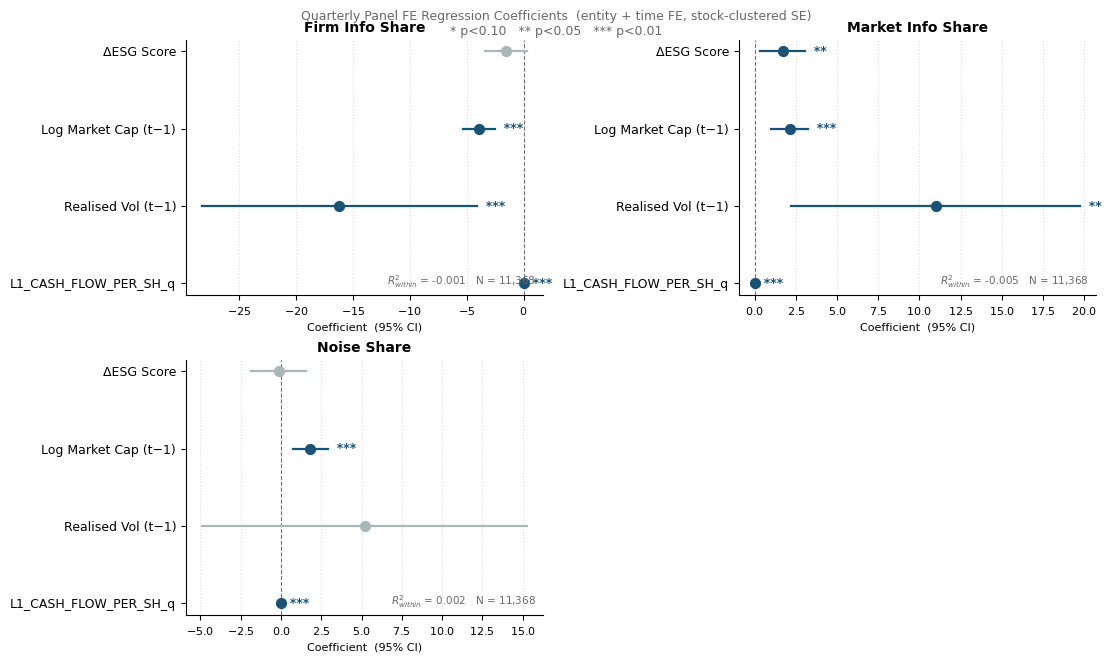

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

VAR_LABELS = {
    # lagged controls
    "L1_ESG_SCORE_q":              "ESG Score (t−1)",
    "L1_LOG_MKT_CAP_q":            "Log Market Cap (t−1)",
    "L1_VOLATILITY_90D_q":         "90d Volatility (t−1)",
    "L1_REALISED_VOL_Q_q":         "Realised Vol (t−1)",
    "L1_FNCL_LVRG_q":              "Financial Leverage (t−1)",
    "L1_PROF_MARGIN_q":            "Profit Margin (t−1)",
    "L1_GOVERNANCE_SCORE_q":       "Governance Score (t−1)",
    "L1_ENVIRONMENTAL_SCORE_q":    "Environmental Score (t−1)",
    "L1_SOCIAL_SCORE_q":           "Social Score (t−1)",
    "L1_RETURN_COM_EQY_q":         "Return on Equity (t−1)",
    "L1_PCT_INSIDER_SHARES_OUT_q": "Insider Ownership (t−1)",
    "L1_ESG_DISCLOSURE_SCORE_q":   "ESG Disclosure (t−1)",
    # first differences
    "D_ESG_SCORE_q":               "ΔESG Score",
    "D_ESG_DISCLOSURE_SCORE_q":    "ΔESG Disclosure",
    "D_GOVERNANCE_SCORE_q":        "ΔGovernance Score",
    "D_ENVIRONMENTAL_SCORE_q":     "ΔEnvironmental Score",
    "D_SOCIAL_SCORE_q":            "ΔSocial Score",
    "D_LOG_MKT_CAP_q":             "Δ Log Market Cap",
    "D_VOLATILITY_90D_q":          "Δ 90d Volatility",
    # levels
    "CASH_FLOW_PER_SH_q":          "Cash Flow per Share",
    "PROF_MARGIN_q":               "Profit Margin",
    "FNCL_LVRG_q":                 "Financial Leverage",
}
OUTCOME_LABELS = {
    "FirmInfoShare": "Firm Info Share",
    "MktInfoShare":  "Market Info Share",
    "NoiseShare":    "Noise Share",
}

def _stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def plot_coef_grid(results, save_path=None):
    visible = [r for r in results if r["coef_table"]]
    if not visible:
        print("No results with coefficients to plot.")
        return
    n = len(visible)
    ncols = min(2, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows), constrained_layout=True)
    axes = np.array(axes).flatten()

    for ax, r in zip(axes, visible):
        rows   = r["coef_table"]
        labels = [VAR_LABELS.get(d["variable"], d["variable"]) for d in rows]
        coefs  = [d["coef"]     for d in rows]
        lows   = [d["lower_95"] for d in rows]
        highs  = [d["upper_95"] for d in rows]
        pvals  = [d["p_value"]  for d in rows]
        y_pos  = range(len(rows) - 1, -1, -1)

        for y, coef, lo, hi, p in zip(y_pos, coefs, lows, highs, pvals):
            color = "#1a5276" if p < 0.10 else "#aab7b8"
            ax.plot([lo, hi], [y, y], color=color, lw=1.6, zorder=2)
            ax.scatter([coef], [y], color=color, s=50, zorder=3)
            stars = _stars(p)
            if stars:
                ax.text(hi, y, f"  {stars}", va="center", ha="left",
                        fontsize=9, color="#1a5276", fontweight="bold")

        ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.6, zorder=1)
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(labels, fontsize=9)
        ax.tick_params(axis="x", labelsize=8)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style="sci", axis="x", scilimits=(-3, 3))
        ax.set_title(OUTCOME_LABELS.get(r["outcome"], r["outcome"]),
                     fontsize=10, fontweight="bold", pad=6)
        ax.set_xlabel("Coefficient  (95% CI)", fontsize=8)
        r2    = r["r_square"]
        n_obs = r["n_obs"]
        note  = (f"$R^2_{{within}}$ = {r2:.3f}   N = {n_obs:,}"
                 if not (isinstance(r2, float) and np.isnan(r2)) else f"N = {n_obs:,}")
        ax.text(0.98, 0.02, note, transform=ax.transAxes,
                fontsize=7.5, ha="right", va="bottom", color="dimgray")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="x", ls=":", alpha=0.4, zorder=0)

    for ax in axes[len(visible):]:
        ax.set_visible(False)

    fig.suptitle(
        "Quarterly Panel FE Regression Coefficients  (entity + time FE, stock-clustered SE)\n"
        "* p<0.10   ** p<0.05   *** p<0.01",
        fontsize=9, color="dimgray", y=1.01
    )
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


plot_path = OUTPUTS_DIR / f"quarterly_coef_plot{RUN_TAG}.png"
plot_coef_grid(results, save_path=plot_path)